To run after filtered description of cores. Here PCA figures and outlier (removed cores for clustering) are recognized

In [ ]:
from notebook_utils import cd2parent
cd2parent()

In [2]:
import pandas as pd
import numpy as np
import os

from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
from src.dataloader import Dataloader
dataloader = Dataloader()

In [4]:
dataloader.load_descriptions_selected()

In [7]:
df = dataloader.descriptions_selected.set_index('smiles')
df

,QeD,logP,TPSA,SMR_VSA3,SlogP_VSA3,MR,NumNatoms,NumOatoms,dipole,PMI1,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF
smiles,,,,,,,,,,,,,,,
C1NCC12CNO2,0.403605,-1.1368,33.29,10.782935,4.837589,24.6884,2,1,3.87714,81.244835,0.012257,0.945469,0.335358,0.507082,0.718026
C1NCC12CNC2,0.413406,-0.8208,24.06,10.619627,0.000000,28.1724,2,0,1.99457,85.552443,0.011604,0.941199,0.319372,0.661015,0.766013
C1NCC12COC2,0.446167,-0.3938,21.26,5.309813,4.736863,26.1217,1,1,2.52334,82.895966,0.012035,0.946231,0.338602,0.737560,0.798354
C1CC2(CNC2)N1,0.419327,-0.6783,24.06,10.619627,0.000000,28.2204,2,0,2.26480,86.138871,0.011504,0.937728,0.307329,0.539355,0.699706
C1CNC2(C1)CNC2,0.449822,-0.2882,24.06,10.619627,0.000000,32.8374,2,0,1.15946,120.985019,0.007779,0.931523,0.279286,0.605799,0.834604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1NCC12CN2,0.366447,-1.0684,33.97,10.619627,0.000000,23.6034,2,0,2.80086,63.887166,0.014035,0.938969,0.297353,0.448359,0.647464
C1CC12CNC2,0.445886,0.3698,12.03,5.309813,0.000000,24.5367,1,0,1.48063,66.686223,0.013577,0.934704,0.284426,0.529917,0.712683
C1CC2(C1)CO2,0.397789,0.9393,12.53,0.000000,4.736863,22.5340,0,1,2.19762,65.631702,0.013647,0.935161,0.284896,0.426321,0.593223


In [16]:
from src.paths import DIR_DATA, DIR_CORES, DIR_COMP
dir_pca_files = os.path.join(DIR_DATA, DIR_CORES, DIR_COMP)

In [9]:
std_scaler = StandardScaler()

In [10]:
descs = pd.DataFrame(std_scaler.fit_transform(df), columns=df.columns, index = df.index)

In [11]:
pca = PCA(n_components=descs.shape[1])

In [12]:
pca.fit(descs)
pcaDF=pd.DataFrame( pca.transform(descs)[...,:3],
                 columns=["PC1","PC2","PC3"],index=descs.index)

In [13]:
print((pca.explained_variance_ratio_[:3]*100).tolist())

[35.92901766895095, 20.675938615809773, 14.98341167892935]


In [14]:
sum(pca.explained_variance_ratio_[:3])*100

np.float64(71.58836796369008)

In [ ]:
pcaDF.to_csv(os.path.join(dir_pca_files,"PCAscore.csv"))

In [17]:
loadDF = pd.DataFrame(pca.components_[:3], columns=descs.columns)

In [18]:
loadDF

,QeD,logP,TPSA,SMR_VSA3,SlogP_VSA3,MR,NumNatoms,NumOatoms,dipole,PMI1,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF
0,0.218937,-0.184592,0.194907,0.343037,-0.136739,0.361466,0.381710,-0.148750,0.012271,0.379642,-0.334547,-0.150503,-0.165148,0.220175,0.300901
1,-0.003100,-0.321667,0.458382,0.203179,0.401734,0.043330,0.108540,0.300687,0.367509,-0.011998,0.031886,0.303684,0.334294,-0.183015,-0.077268
2,0.529549,0.406604,-0.088875,0.018162,-0.013823,0.252166,-0.106602,-0.221613,-0.071514,0.155024,-0.185660,0.295498,0.311209,-0.370237,-0.192109


In [ ]:
loadDF.to_csv(os.path.join(dir_pca_files,"PCAloads.csv"), index=False)

# Variances

In [19]:
from src.plot_utils import gradientbars_sliced, truncate_colormap

In [20]:
cumColor  = truncate_colormap( plt.get_cmap("GnBu").reversed(), minval=.2 )
absColor  = truncate_colormap( plt.get_cmap("YlOrBr"), minval=.2 )

In [21]:
variances = np.vstack((pca.explained_variance_ratio_, np.cumsum(pca.explained_variance_ratio_)))

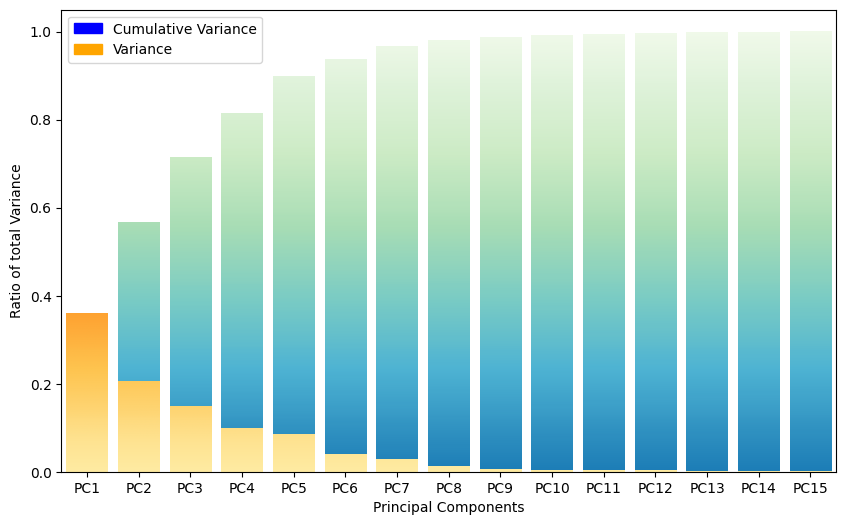

In [32]:
plt.figure(figsize=(10,6))

barCum = plt.bar(range(variances.shape[1]), variances[1], label = "Cumulative Variance",)
gradientbars_sliced(barCum, cumColor)

barAbs=plt.bar(range(variances.shape[1]), variances[0], label = "Variance", )
gradientbars_sliced(barAbs, absColor)

plt.ylabel("Ratio of total Variance")
plt.xlabel("Principal Components")
plt.xticks(range(variances.shape[1]), [f"PC{_+1}" for _ in range(variances.shape[1]) ] )

leg = plt.legend()
leg.legend_handles[0].set_color('blue')
leg.legend_handles[1].set_color('orange')

fig = plt.gcf()

plt.xlim(-.5, variances.shape[1]-.5)
plt.show()

In [33]:
fig.savefig("figures/pca/variance.png",bbox_inches="tight")

## Loadings

In [24]:
pc1Color = truncate_colormap( plt.get_cmap("seismic") )
pc2Color = truncate_colormap( plt.get_cmap("PiYG") )
pc3Color = truncate_colormap( plt.get_cmap("BrBG") )

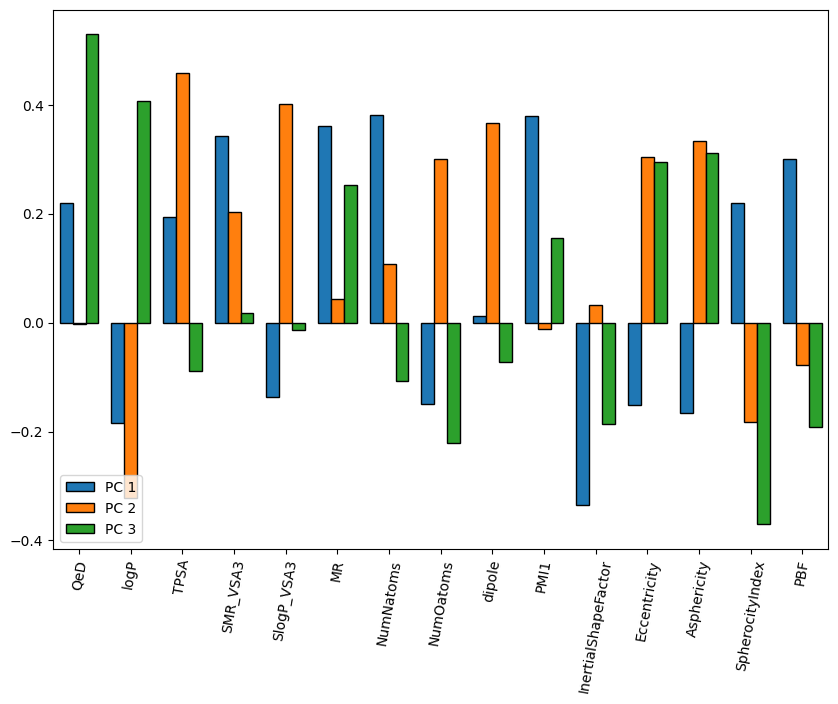

In [27]:
plt.figure(figsize=(10,7))
widthBar = .25
delta = widthBar
positions = np.array(range(loadDF.shape[1]))

barPC1 = plt.bar(positions-delta, loadDF.iloc[0], width=widthBar, label="PC 1", align="center", edgecolor="black")
barPC2 = plt.bar(positions, loadDF.iloc[1], width=widthBar, label="PC 2", align="center", edgecolor="black")
barPC3 = plt.bar(positions+delta, loadDF.iloc[2], width=widthBar, label="PC 3", align="center", edgecolor="black")

plt.xticks(range(loadDF.shape[1]), loadDF.columns, rotation=80)
plt.xlim(-delta-widthBar, positions[-1]+widthBar+delta)

plt.legend(loc="lower left")
fig = plt.gcf()

plt.show()

In [28]:
fig.savefig("figures/pca/loading.png",bbox_inches="tight")

# Outliers cores pre clustering

In [34]:
from src.plot_utils import gradientbars_sliced, truncate_colormap

In [35]:
OrReMap = truncate_colormap(plt.get_cmap("OrRd"), minval=.2,  maxval=1)

In [36]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=1)

In [37]:
preds = lof.fit_predict(pcaDF[[f"PC{i+1}" for i in range(3)]])

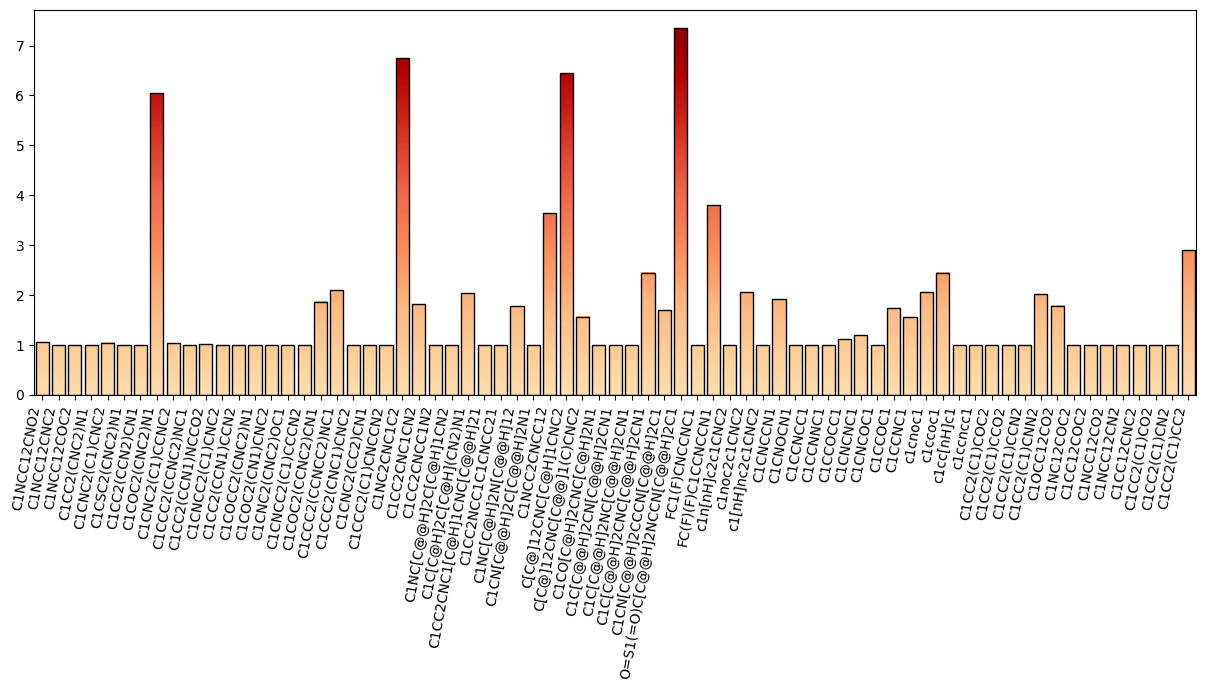

In [40]:
fig = plt.figure(figsize=(15,5))
barOutliers=plt.bar(range(len(pcaDF.index)), np.abs(lof.negative_outlier_factor_),edgecolor="black")
plt.xlim(-0.5, len(pcaDF.index)-.5)
plt.xticks(range(len(pcaDF.index)), pcaDF.index, rotation=80, ha='right')
gradientbars_sliced(barOutliers, OrReMap)

In [41]:
fig.savefig('figures/pca/outliers.png',bbox_inches="tight")

In [42]:
smi_to_drop = pcaDF[np.abs(lof.negative_outlier_factor_) >= 5].index.tolist()
smi_to_drop

['C1COC2(CNC2)N1',
 'C1NC2CNC1C2',
 'C[C@]12CNC[C@H]1CNC2',
 'O=S1(=O)C[C@@H]2NCCN[C@@H]2C1']

In [43]:
from rdkit.Chem import Draw
from rdkit import Chem

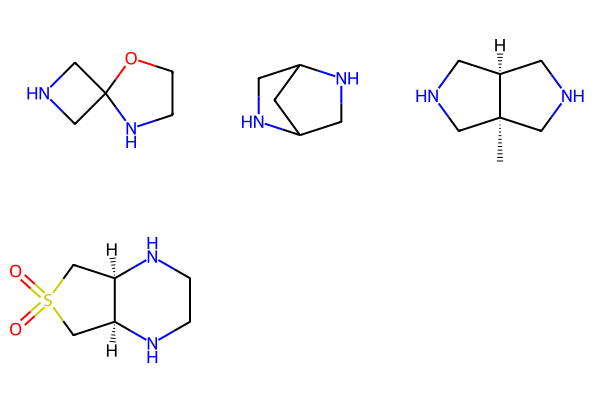

In [44]:
Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in smi_to_drop])

In [ ]:
pcaDF.drop(index=smi_to_drop).to_csv(os.path.join(dir_pca_files,'PCAscore_def.csv'))